# Ejercicio 4 — Análisis exploratorio con DuckDB

Análisis de los viajes de **2026** (enero–agosto, los meses publicados) sobre la vista `viajes_validos`, que lee los Parquet directamente y aplica las reglas de calidad del Ejercicio 3. Las consultas están en [`sql/04_analisis_exploratorio.sql`](../sql/04_analisis_exploratorio.sql); el filtro `anio = 2026` fija el alcance aunque luego se descarguen otros años.

In [1]:
import sys

import matplotlib.pyplot as plt
import pandas as pd

sys.path.append("../scripts")
from lab import conectar_parquet, consultas, mostrar

pd.set_option("display.max_columns", None)
con = conectar_parquet()
Q = consultas("04_analisis_exploratorio.sql")

## 4.1 Preguntas de análisis

Las preguntas salen de lo que el conjunto de datos permite medir (Ejercicio 3): fechas al segundo, zonas de origen y destino, distancia, desglose completo del cobro y forma de pago, para dos flotas con reglas distintas (los taxis verdes solo pueden recoger pasajeros en la calle fuera del sur de Manhattan y de los aeropuertos).

| # | Dimensión | Pregunta | Por qué es relevante con estos datos |
|---|---|---|---|
| P1 | Temporal | ¿Cómo varía la cantidad de viajes por mes y tipo de taxi? | Cada archivo es un mes; permite ver estacionalidad |
| P2 | Temporal | ¿En qué días de la semana y horas se concentra la demanda? | Las fechas tienen precisión de segundos |
| P3 | Características | ¿Cuál es la distancia, duración, velocidad y ocupación típica? | `trip_distance`, duración derivada de las fechas y `passenger_count` |
| P4 | Amarillos vs verdes | ¿En qué se diferencian los viajes de cada tipo? | Dos flotas reguladas de forma distinta |
| P5 | Amarillos vs verdes | ¿Desde qué zonas se originan los viajes de cada tipo? | `PULocationID` (zonas de la TLC) |
| P6 | Pago | ¿Cómo pagan los pasajeros y cómo cambia la propina según la forma de pago? | `payment_type` y `tip_amount` |
| P7 | Pago | ¿Qué parte de lo cobrado es tarifa, propina, peajes y recargos? | El total viene desglosado, incluido el cargo CBD de 2025 |
| P8 | Distribución | ¿Cómo se distribuyen la distancia y el monto total? | Variables continuas con colas largas |
| P9 | Atípicos | ¿Cuántos viajes válidos tienen un total atípico y qué son? | Separar valores extremos legítimos de errores |
| P10 | Inconsistencias | ¿Qué inconsistencias internas tienen los registros originales? | El total debería ser la suma de sus componentes |

## 4.2–4.4 Consultas, documentación y resultados

Cada consulta se imprime antes de su resultado; su objetivo está en el comentario `-- Pregunta N`.

### P1. Viajes por mes y tipo de taxi

In [2]:
p1 = mostrar(con, Q["4.P1_viajes_por_mes"])
p1

-- Pregunta 1: como varia la cantidad de viajes por mes y tipo de taxi?
PIVOT (SELECT mes, tipo_taxi FROM viajes_validos WHERE anio = 2026)
ON tipo_taxi USING count(*)
GROUP BY mes
ORDER BY mes;


,mes,green,yellow
0,1,38062,3514484
1,2,35092,3208135
2,3,41648,3760067
3,4,41545,3671397
4,5,42309,3909335
5,6,41519,3643715
6,7,38565,3343680
7,8,38043,3161428


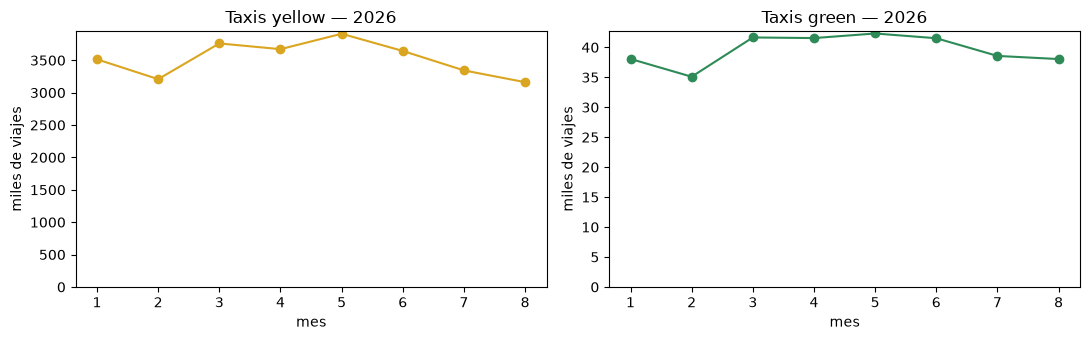

In [3]:
fig, ejes = plt.subplots(1, 2, figsize=(11, 3.5))
for eje, tipo, color in zip(ejes, ["yellow", "green"], ["goldenrod", "seagreen"]):
    eje.plot(p1["mes"], p1[tipo] / 1000, marker="o", color=color)
    eje.set(title=f"Taxis {tipo} — 2026", xlabel="mes", ylabel="miles de viajes", xticks=p1["mes"])
    eje.set_ylim(bottom=0)
plt.tight_layout()

**Resultado:** los amarillos van de 3.16 millones de viajes (agosto) a 3.91 millones (mayo); los verdes, de 35 mil (febrero) a 42 mil (mayo). Ambos tipos siguen el mismo patrón: suben en primavera (marzo–mayo) y bajan en febrero (mes más corto) y en julio–agosto (vacaciones de verano).

### P2. Demanda por día de la semana y hora

In [4]:
p2 = mostrar(con, Q["4.P2_dia_hora"])
p2.head()

-- Pregunta 2: en que dias de la semana y horas se concentra la demanda?
-- Promedio de viajes por hora calendario (dia de la semana x hora), ambos tipos.
SELECT isodow(pickup_datetime)                              AS dia_semana,  -- 1 = lunes
       hour(pickup_datetime)                                AS hora,
       count(*) / count(DISTINCT CAST(pickup_datetime AS DATE)) AS viajes_promedio
FROM viajes_validos
WHERE anio = 2026
GROUP BY ALL
ORDER BY dia_semana, hora;


,dia_semana,hora,viajes_promedio
0,1,0,1926.257143
1,1,1,988.200000
2,1,2,560.457143
3,1,3,435.971429
4,1,4,590.942857


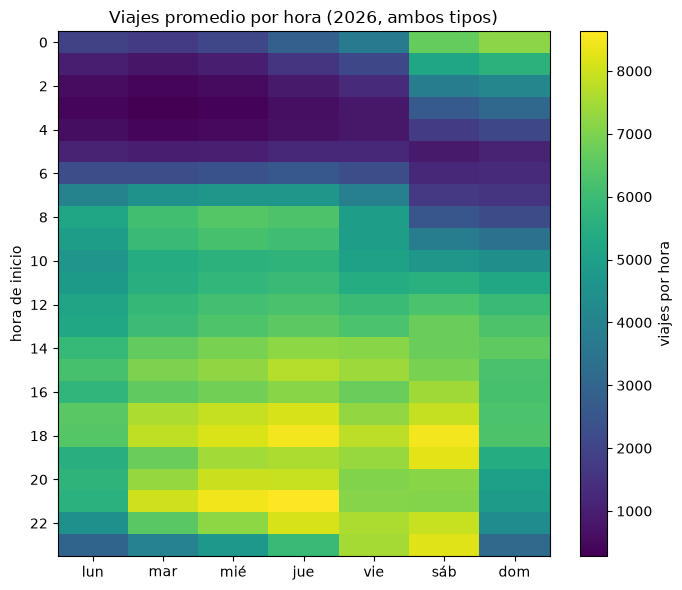

In [5]:
matriz = p2.pivot(index="hora", columns="dia_semana", values="viajes_promedio")
fig, eje = plt.subplots(figsize=(7, 6))
imagen = eje.imshow(matriz, aspect="auto", cmap="viridis")
eje.set(xticks=range(7), xticklabels=["lun", "mar", "mié", "jue", "vie", "sáb", "dom"],
        yticks=range(0, 24, 2), ylabel="hora de inicio", title="Viajes promedio por hora (2026, ambos tipos)")
fig.colorbar(imagen, label="viajes por hora")
plt.tight_layout()

**Resultado:** de lunes a viernes la demanda sube desde las 7 h y alcanza su máximo entre las 17 y las 21 h (hasta ~8,600 viajes por hora el jueves a las 21 h). Los fines de semana el patrón se desplaza: a las 0 h del sábado y del domingo (viernes y sábado por la noche) hay 6,652 y 7,181 viajes por hora, contra 1,700–2,900 de lunes a jueves, y la mañana es mucho más tranquila. El mínimo está entre las 3 y las 5 h.

### P3. Características típicas de un viaje

In [6]:
mostrar(con, Q["4.P3_caracteristicas"])

-- Pregunta 3: cual es la distancia, duracion, velocidad y ocupacion tipica de un viaje?
SELECT tipo_taxi,
       count(*)                                         AS viajes,
       round(quantile_cont(trip_distance, 0.25), 2)     AS distancia_p25_mi,
       round(quantile_cont(trip_distance, 0.50), 2)     AS distancia_p50_mi,
       round(quantile_cont(trip_distance, 0.75), 2)     AS distancia_p75_mi,
       round(quantile_cont(duracion_min, 0.50), 1)      AS duracion_p50_min,
       round(quantile_cont(velocidad_mph, 0.50), 1)     AS velocidad_p50_mph,
       round(avg(passenger_count), 2)                   AS pasajeros_promedio,
       round(100.0 * count_if(passenger_count = 1) / count(passenger_count), 1) AS pct_un_pasajero
FROM viajes_validos
WHERE anio = 2026
GROUP BY tipo_taxi
ORDER BY tipo_taxi;


,tipo_taxi,viajes,distancia_p25_mi,distancia_p50_mi,distancia_p75_mi,duracion_p50_min,velocidad_p50_mph,pasajeros_promedio,pct_un_pasajero
0,green,316783,1.32,2.12,3.71,13.2,10.0,1.30,82.8
1,yellow,28212241,1.10,1.93,3.95,14.1,9.3,1.25,82.3


**Resultado:** el viaje típico es corto y lento: mediana de 1.93 millas y 14.1 minutos en amarillos (2.12 millas y 13.2 minutos en verdes), con una velocidad mediana de 9–10 mph, propia del tráfico urbano. El 82% de los viajes lleva un solo pasajero (promedio 1.25–1.30, calculado solo sobre los registros que informan `passenger_count`).

### P4. Diferencias entre amarillos y verdes

In [7]:
mostrar(con, Q["4.P4_amarillo_vs_verde"])

-- Pregunta 4: en que se diferencian los viajes de taxis amarillos y verdes?
SELECT tipo_taxi,
       count(*)                                                       AS viajes,
       round(100.0 * count(*) / sum(count(*)) OVER (), 2)             AS pct_viajes,
       round(avg(trip_distance), 2)                                   AS distancia_prom_mi,
       round(avg(fare_amount), 2)                                     AS tarifa_prom,
       round(avg(total_amount), 2)                                    AS total_prom,
       round(sum(fare_amount) / sum(trip_distance), 2)                AS tarifa_por_milla,
       round(100.0 * count_if(RatecodeID IN (2, 3)) / count(*), 2)    AS pct_tarifa_aeropuerto,
       round(100.0 * count_if(cbd_congestion_fee > 0) / count(*), 2)  AS pct_cobro_cbd,
       round(100.0 * count_if(trip_type = 2) / count(*), 2)           AS pct_despachados
FROM viajes_validos
WHERE anio = 2026
GROUP BY tipo_taxi
ORDER BY tipo_taxi;


,tipo_taxi,viajes,pct_viajes,distancia_prom_mi,tarifa_prom,total_prom,tarifa_por_milla,pct_tarifa_aeropuerto,pct_cobro_cbd,pct_despachados
0,green,316783,1.11,3.29,16.95,25.29,5.15,0.25,8.46,3.01
1,yellow,28212241,98.89,3.51,21.30,30.24,6.07,2.63,72.42,NaN


**Resultado:** los amarillos hacen el 98.9% de los viajes. Sus viajes son algo más largos (3.51 vs 3.29 millas promedio), más caros (total promedio USD 30.24 vs 25.29) y con mayor tarifa por milla. Las diferencias más grandes vienen de la regulación: 2.6% de los amarillos usa tarifa de aeropuerto (JFK/Newark) contra 0.25% de los verdes, y el cargo por entrar a la zona de congestión de Manhattan (CBD) aparece en 72% de los amarillos pero solo en 8.5% de los verdes. Solo 3% de los viajes verdes fue despachado (`trip_type = 2`); el resto se tomó en la calle.

### P5. Zonas de origen principales

In [8]:
mostrar(con, Q["4.P5_zonas_origen"])

-- Pregunta 5: desde que zonas (PULocationID, TLC Taxi Zones) se originan los viajes de cada tipo?
SELECT tipo_taxi,
       PULocationID                                                         AS zona_origen,
       count(*)                                                             AS viajes,
       round(100.0 * count(*) / sum(count(*)) OVER (PARTITION BY tipo_taxi), 2) AS pct_del_tipo
FROM viajes_validos
WHERE anio = 2026
GROUP BY tipo_taxi, PULocationID
QUALIFY row_number() OVER (PARTITION BY tipo_taxi ORDER BY count(*) DESC) <= 5
ORDER BY tipo_taxi, viajes DESC;


,tipo_taxi,zona_origen,viajes,pct_del_tipo
0,green,74,86830,27.41
1,green,75,41695,13.16
2,green,95,15621,4.93
3,green,43,12985,4.10
4,green,166,12436,3.93
5,yellow,237,1252523,4.44
6,yellow,161,1171241,4.15
7,yellow,132,1124278,3.99
8,yellow,236,1112961,3.94
9,yellow,186,868410,3.08


**Resultado** (nombres según el [TLC Taxi Zone Lookup](https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv)): los verdes están muy concentrados, ya que East Harlem North (74) y East Harlem South (75) generan 40.6% de sus viajes, seguidos de Forest Hills (95), Central Park (43) y Morningside Heights (166). Los amarillos están dispersos: su zona principal, Upper East Side South (237), concentra solo 4.4%, seguida de Midtown Center (161), JFK Airport (132), Upper East Side North (236) y Penn Station (186). Las dos flotas atienden mercados geográficos casi disjuntos.

### P6. Forma de pago y propina

In [9]:
mostrar(con, Q["4.P6_forma_pago"])

-- Pregunta 6: como pagan los pasajeros y como cambia la propina segun la forma de pago?
SELECT tipo_taxi,
       forma_pago,
       count(*)                                                                 AS viajes,
       round(100.0 * count(*) / sum(count(*)) OVER (PARTITION BY tipo_taxi), 2) AS pct_del_tipo,
       round(avg(tip_amount), 2)                                                AS propina_prom,
       round(100.0 * sum(tip_amount) / sum(fare_amount), 1)                     AS propina_pct_tarifa
FROM viajes_validos
WHERE anio = 2026
GROUP BY tipo_taxi, forma_pago
ORDER BY tipo_taxi, viajes DESC;


,tipo_taxi,forma_pago,viajes,pct_del_tipo,propina_prom,propina_pct_tarifa
0,green,Tarjeta,210856,66.56,3.79,21.0
1,green,Efectivo,62390,19.69,0.00,0.0
2,green,Desconocido,42651,13.46,0.85,8.0
3,green,Sin cargo,637,0.20,0.01,0.0
4,green,Disputa,249,0.08,0.00,0.0
5,yellow,Tarjeta,18451474,65.40,4.26,21.6
6,yellow,Flex fare / sin dato,7033351,24.93,0.40,1.6
7,yellow,Efectivo,2553853,9.05,0.00,0.0
8,yellow,Disputa,117797,0.42,0.00,0.0
9,yellow,Sin cargo,55766,0.20,0.00,0.0


**Resultado:** dos de cada tres viajes se pagan con tarjeta en ambos tipos; el efectivo pesa más en verdes (19.7%) que en amarillos (9.1%). La propina solo queda registrada cuando se paga con tarjeta: 21.6% de la tarifa en amarillos y 21.0% en verdes, mientras que en efectivo siempre es 0. El 24.9% de los amarillos tiene `payment_type = 0` ("Flex fare / sin dato"), con propina promedio de USD 0.40. Por eso **la propina solo se analiza en pagos con tarjeta**.

### P7. Composición de lo cobrado

In [10]:
mostrar(con, Q["4.P7_composicion_total"])

-- Pregunta 7: que parte de lo cobrado corresponde a tarifa, propina, peajes y recargos?
SELECT tipo_taxi,
       round(sum(total_amount) / 1e6, 1)                                         AS total_millones_usd,
       round(100.0 * sum(fare_amount) / sum(total_amount), 1)                    AS pct_tarifa,
       round(100.0 * sum(tip_amount) / sum(total_amount), 1)                     AS pct_propina,
       round(100.0 * sum(tolls_amount) / sum(total_amount), 1)                   AS pct_peajes,
       round(100.0 * sum(congestion_surcharge) / sum(total_amount), 1)           AS pct_congestion,
       round(100.0 * sum(cbd_congestion_fee) / sum(total_amount), 1)            AS pct_cbd,
       round(100.0 * coalesce(sum(Airport_fee), 0) / sum(total_amount), 1)       AS pct_aeropuerto,
       round(100.0 * sum(extra + mta_tax + improvement_surcharge) / sum(total_amount), 1) AS pct_otros
FROM viajes_validos
WHERE anio = 2026
GROUP BY tipo_taxi
ORDER BY tipo_taxi;


,tipo_taxi,total_millones_usd,pct_tarifa,pct_propina,pct_peajes,pct_congestion,pct_cbd,pct_aeropuerto,pct_otros
0,green,8.0,67.0,10.4,1.2,3.1,0.3,0.0,9.2
1,yellow,853.2,70.4,9.5,1.8,5.6,1.8,0.4,8.7


**Resultado:** la tarifa es ~70% de lo cobrado en amarillos (67% en verdes) y la propina ~10%. Los recargos de congestión suman 7.4% en amarillos (5.6% del recargo estatal y 1.8% del cargo CBD) y solo 3.4% en verdes, que circulan poco por el sur de Manhattan. Entre enero y agosto se cobraron USD 853 millones en viajes amarillos válidos y USD 8 millones en verdes. Los porcentajes no suman exactamente 100 por la inconsistencia descrita en P10.

### P8. Distribución de la distancia y del monto total

In [11]:
p8d = mostrar(con, Q["4.P8_distribucion_distancia"])
p8d.pivot(index="milla_desde", columns="tipo_taxi", values="pct_del_tipo").T

-- Pregunta 8: como se distribuye la distancia de los viajes? (intervalos de 1 milla, ultimo abierto)
SELECT least(floor(trip_distance), 20)::INTEGER                                   AS milla_desde,
       tipo_taxi,
       count(*)                                                                    AS viajes,
       round(100.0 * count(*) / sum(count(*)) OVER (PARTITION BY tipo_taxi), 2)    AS pct_del_tipo
FROM viajes_validos
WHERE anio = 2026
GROUP BY milla_desde, tipo_taxi
ORDER BY tipo_taxi, milla_desde;


milla_desde,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20
tipo_taxi,,,,,,,,,,,,,,,,,,,,,
green,13.80,32.94,20.19,10.62,4.85,3.45,3.35,2.29,1.76,1.30,1.08,0.82,0.67,0.59,0.44,0.34,0.34,0.30,0.23,0.15,0.49
yellow,20.97,30.25,15.74,8.29,5.11,3.56,2.64,2.08,1.95,1.76,1.36,0.95,0.58,0.43,0.39,0.41,0.69,0.95,0.67,0.39,0.84


In [12]:
p8t = mostrar(con, Q["4.P8_distribucion_total"])
p8t.pivot(index="usd_desde", columns="tipo_taxi", values="pct_del_tipo").T

-- Pregunta 8: como se distribuye el monto total pagado? (intervalos de 5 USD, ultimo abierto)
SELECT least(floor(total_amount / 5) * 5, 150)::INTEGER                            AS usd_desde,
       tipo_taxi,
       count(*)                                                                    AS viajes,
       round(100.0 * count(*) / sum(count(*)) OVER (PARTITION BY tipo_taxi), 2)    AS pct_del_tipo
FROM viajes_validos
WHERE anio = 2026
GROUP BY usd_desde, tipo_taxi
ORDER BY tipo_taxi, usd_desde;


usd_desde,0,5,10,15,20,25,30,35,40,45,50,55,60,65,70,75,80,85,90,95,100,105,110,115,120,125,130,135,140,145,150
tipo_taxi,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
green,0.17,5.00,19.16,23.68,16.48,11.34,7.06,4.23,3.14,2.49,1.86,1.17,0.90,0.63,0.51,0.39,0.30,0.26,0.25,0.17,0.18,0.11,0.08,0.05,0.07,0.04,0.04,0.02,0.03,0.02,0.15
yellow,0.01,1.13,12.77,22.38,18.45,12.67,8.44,5.85,3.92,2.67,1.78,1.38,1.17,1.04,0.93,0.76,0.83,0.66,0.66,0.69,0.79,0.33,0.13,0.09,0.07,0.06,0.05,0.04,0.03,0.03,0.18


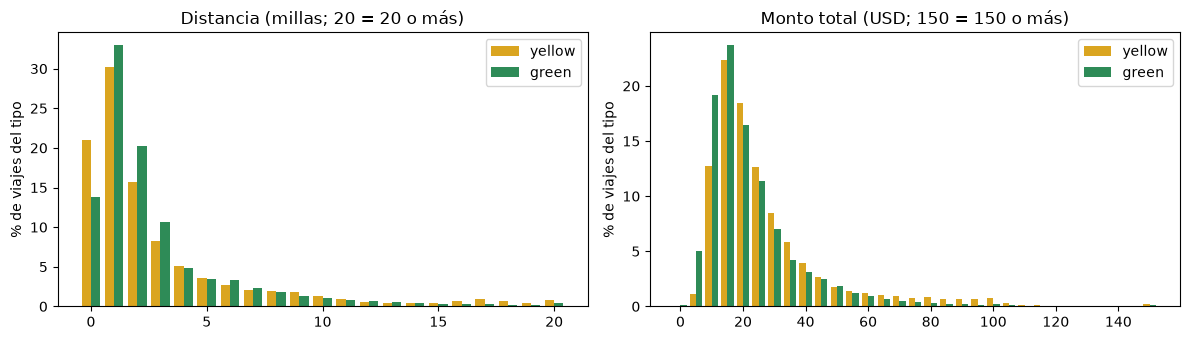

In [13]:
fig, ejes = plt.subplots(1, 2, figsize=(12, 3.5))
for eje, datos, x, titulo in [(ejes[0], p8d, "milla_desde", "Distancia (millas; 20 = 20 o más)"),
                              (ejes[1], p8t, "usd_desde", "Monto total (USD; 150 = 150 o más)")]:
    tabla = datos.pivot(index=x, columns="tipo_taxi", values="pct_del_tipo")
    ancho = (tabla.index[1] - tabla.index[0]) * 0.4
    eje.bar(tabla.index - ancho / 2, tabla["yellow"], width=ancho, color="goldenrod", label="yellow")
    eje.bar(tabla.index + ancho / 2, tabla["green"], width=ancho, color="seagreen", label="green")
    eje.set(title=titulo, ylabel="% de viajes del tipo")
    eje.legend()
plt.tight_layout()

**Resultado:** ambas distribuciones son asimétricas a la derecha. El intervalo de 1–2 millas concentra 30–33% de los viajes y solo 5–8% supera las 10 millas. El total más frecuente está entre USD 15 y 20. Los amarillos tienen un segundo pico en 16–18 millas y en USD 75–105, consistente con los viajes entre Manhattan y JFK (tarifa fija más recargos). Por eso la media es mayor que la mediana y se reportan percentiles.

### P9. Valores atípicos dentro de los viajes válidos

In [14]:
mostrar(con, Q["4.P9_atipicos_iqr"])

-- Pregunta 9: cuantos viajes validos tienen un total atipico segun la regla de Tukey (Q3 + 1.5 IQR)?
WITH cuartiles AS (
    SELECT tipo_taxi,
           quantile_cont(total_amount, 0.25) AS q1,
           quantile_cont(total_amount, 0.75) AS q3
    FROM viajes_validos
    WHERE anio = 2026
    GROUP BY tipo_taxi
)
SELECT v.tipo_taxi,
       round(q1, 2)                                                          AS q1,
       round(q3, 2)                                                          AS q3,
       round(q3 + 1.5 * (q3 - q1), 2)                                        AS limite_superior,
       count_if(total_amount > q3 + 1.5 * (q3 - q1))::BIGINT                 AS atipicos,
       round(100.0 * count_if(total_amount > q3 + 1.5 * (q3 - q1)) / count(*), 2) AS pct_atipicos,
       round(100.0 * count_if(total_amount > q3 + 1.5 * (q3 - q1) AND RatecodeID IN (2, 3, 4))
             / nullif(count_if(total_amount > q3 + 1.5 * (q3 - q1)), 0), 1)  AS pct_atipicos_aeropuerto_o_fuera_n

,tipo_taxi,q1,q3,limite_superior,atipicos,pct_atipicos,pct_atipicos_aeropuerto_o_fuera_nyc
0,green,15.0,29.51,51.28,21020,6.64,5.0
1,yellow,17.5,34.50,60.00,2401739,8.51,32.5


**Resultado:** con la regla de Tukey (Q3 + 1.5·IQR), 8.5% de los viajes amarillos (total > USD 60) y 6.6% de los verdes (> USD 51.28) son atípicos. No son errores: un tercio de los atípicos amarillos usa tarifa de aeropuerto o de fuera de NYC (RatecodeID 2, 3 o 4), y el resto son viajes largos. **Decisión:** no se eliminan. Los errores ya los excluyó `viajes_validos` y estos valores son la cola real de la distribución, así que se resumen con medianas y percentiles.

### P10. Inconsistencias internas de los registros

In [15]:
mostrar(con, Q["4.P10_inconsistencias"])

-- Pregunta 10: que inconsistencias internas tienen los registros originales?
-- Fuente: vista `viajes` (sin limpiar), anio 2026.
SELECT tipo_taxi,
       count(*)                                                              AS registros,
       count_if(abs(total_amount - (fare_amount + extra + mta_tax + tip_amount + tolls_amount
                + improvement_surcharge + coalesce(congestion_surcharge, 0)
                + coalesce(Airport_fee, 0) + coalesce(cbd_congestion_fee, 0))) > 0.01)::BIGINT
                                                                             AS total_no_cuadra,
       count_if(trip_distance = 0 AND fare_amount > 0 AND PULocationID <> DOLocationID)::BIGINT
                                                                             AS distancia_cero_con_zonas_distintas,
       count_if(tip_amount > 0 AND payment_type = 2)::BIGINT                 AS propina_en_efectivo_registrada,
       count_if(RatecodeID = 99)::BIGINT                                   

,tipo_taxi,registros,total_no_cuadra,distancia_cero_con_zonas_distintas,propina_en_efectivo_registrada,ratecode_desconocido
0,green,337114,66970,4936,0,2
1,yellow,29703355,10895756,710529,183,769693


In [16]:
mostrar(con, Q["4.P10_detalle_por_proveedor"])

-- Pregunta 10 (detalle): de que proveedor y forma de pago vienen los totales que no cuadran?
-- diferencia = total_amount - suma de componentes. Fuente: vista `viajes`, amarillos 2026.
SELECT VendorID,
       payment_type,
       round(total_amount - (fare_amount + extra + mta_tax + tip_amount + tolls_amount
             + improvement_surcharge + coalesce(congestion_surcharge, 0)
             + coalesce(Airport_fee, 0) + coalesce(cbd_congestion_fee, 0)), 2) AS diferencia,
       round(avg(extra), 2)                                                     AS extra_prom,
       count(*)                                                                 AS registros
FROM viajes
WHERE anio = 2026 AND tipo_taxi = 'yellow'
GROUP BY ALL
ORDER BY registros DESC
LIMIT 8;


,VendorID,payment_type,diferencia,extra_prom,registros
0,2,1,0.00,1.06,14576254
1,2,0,2.50,0.00,4558830
2,1,1,-3.25,4.05,2440215
3,2,2,0.00,0.87,2212456
4,2,0,0.00,0.00,798599
5,1,1,0.00,0.06,712555
6,1,1,-2.50,3.24,646879
7,1,2,-3.25,3.93,294687


**Resultado:** en 36.7% de los registros amarillos (19.9% de los verdes) `total_amount` no coincide con la suma de sus componentes. El detalle muestra que la diferencia es sistemática y depende del proveedor:

* **Proveedor 1** (diferencia −3.25 o −2.5): incluye el recargo de congestión y el cargo CBD dentro de `extra` **y además** en sus propias columnas, así que se cuentan dos veces.
* **Proveedor 2 con `payment_type = 0`** (diferencia +2.5): el total incluye el recargo de congestión, pero `congestion_surcharge` viene en NULL.

Además hay 710,529 viajes amarillos con distancia 0 entre zonas distintas (falla del taxímetro o GPS) y 769,693 con `RatecodeID = 99` (desconocido). **Decisión:** el gasto se mide siempre con `total_amount` y no reconstruyéndolo desde sus componentes. Los porcentajes de composición (P7) son aproximados.

## 4.5 Hallazgos relevantes

1. **Dos flotas con mercados distintos.** Los amarillos hacen el 98.9% de los viajes y se reparten por Manhattan y JFK. Los verdes concentran el 40.6% de sus viajes en East Harlem, casi no van a aeropuertos (0.25%) ni pagan el cargo CBD (8.5% vs 72%). Compararlos por totales no tiene sentido; hay que usar proporciones.
2. **El calendario define la demanda.** Los días laborables tienen picos de 17 a 21 h; los fines de semana el máximo pasa a la madrugada de sábado y domingo (7,181 viajes por hora a las 0 h del domingo, contra 1,700–2,900 de lunes a jueves). La demanda mensual baja en febrero y en verano.
3. **Los datos de pago son cada vez menos completos.** Uno de cada cuatro viajes amarillos de 2026 tiene `payment_type = 0` y cinco columnas en NULL, y la propina solo existe para pagos con tarjeta (~21.6% de la tarifa). Cualquier análisis de propinas o de forma de pago debe restringirse o aclarar este sesgo.
4. **El total no siempre cuadra con su desglose.** En 36.7% de los registros amarillos, el total no coincide con la suma de componentes por diferencias de reporte entre proveedores (doble conteo en `extra`, recargo omitido). `total_amount` es la medida confiable.